In [43]:
import pandas as pd

data = pd.read_csv("1726562655.0-file_transfer.log")
# data_400_500k_1 = pd.read_csv("1726644283.0-file_transfer.log")
data_400_500k = pd.read_csv("1726731477.0-file_transfer.log")
data_100k = pd.read_csv("file_transfer_1k_20_iters.log")

allowed_file_sizes = [102400, 204800, 307200, 614400, 716800, 819200, 921600, 1048576, 409600, 512000]

data = data[data["file size(bytes)"].isin(allowed_file_sizes)]
# data_400_500k_1 = data_400_500k_1[data_400_500k_1["file size(bytes)"].isin(allowed_file_sizes)]
data_400_500k = data_400_500k[data_400_500k["file size(bytes)"].isin(allowed_file_sizes)]
data_100k = data_100k[data_100k["file size(bytes)"].isin(allowed_file_sizes)]

# save data to csv
# data.to_csv("file_transfer.log", index=False)

data

,file size(bytes),time taken(s),speed(bytes/s)
0,204800,9.176128,22318
1,204800,14.388761,14233
2,204800,11.707157,17493
3,204800,9.253310,22132
4,204800,10.665655,19201
...,...,...,...
174,1048576,57.872958,18118
175,1048576,83.895994,12498
176,1048576,63.432039,16530
177,1048576,264.372183,3966


In [44]:
data_400_500k

,file size(bytes),time taken(s),speed(bytes/s)
0,409600,26.967329,15188
2,409600,45.066630,9088
3,409600,26.457656,15481
4,409600,30.364727,13489
5,409600,15.300414,26770
6,409600,61.351605,6676
8,409600,16.952629,24161
9,409600,11.258648,36380
10,409600,39.690199,10319
11,409600,52.757000,7763


In [45]:
data_100k

,file size(bytes),time taken(s),speed(bytes/s)
0,102400,3.294233,31084
1,102400,3.487780,29359
2,102400,3.581239,28593
3,102400,9.366509,10932
4,102400,3.464108,29560
5,102400,3.512082,29156
6,102400,3.516178,29122
7,102400,3.451093,29671
8,102400,3.615024,28326
9,102400,3.639183,28138


In [46]:
# concatenate data
data = pd.concat([data, data_400_500k, data_100k])

# sort data on file size
data = data.sort_values(by=["file size(bytes)"])

In [47]:
data

,file size(bytes),time taken(s),speed(bytes/s)
37,102400,9.646239,10615
15,102400,3.372275,30365
14,102400,8.000634,12798
13,102400,3.937396,26007
12,102400,3.474236,29474
...,...,...,...
164,1048576,113.627541,9228
163,1048576,377.239986,2779
162,1048576,47.549169,22052
169,1048576,48.155839,21774


In [48]:
data.columns

Index(['file size(bytes)', ' time taken(s)', ' speed(bytes/s)'], dtype='object')

In [49]:
# divide file size by 1024 to get file size in KB
data["file size(KB)"] = data["file size(bytes)"] / 1024

# multiply speed by 8 to get speed in bits and divide by 1024 to get speed in Kbps
data["speed(Kbps)"] = data[" speed(bytes/s)"] * 8 / 1024

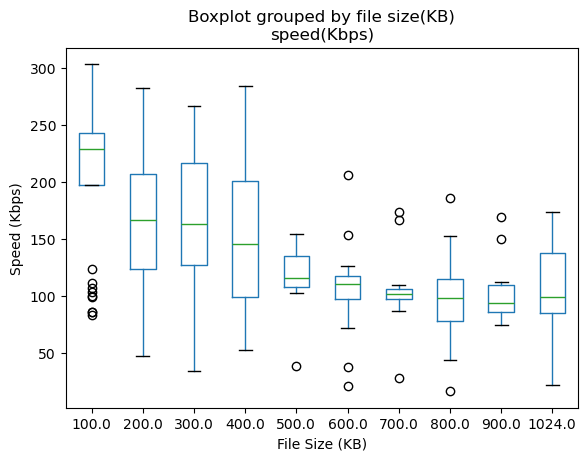

In [50]:
# plot box plot of varying file sizes and speeds

import matplotlib.pyplot as plt

# plt.figure(figsize=(10, 6))
# plt.title("File size vs Speed")

data.boxplot(column="speed(Kbps)", by="file size(KB)", grid=False)
plt.xlabel("File Size (KB)")
plt.ylabel("Speed (Kbps)")
plt.show()

In [51]:
# print unique values in the column
print(data['file size(bytes)'].unique())

[ 102400  204800  307200  409600  512000  614400  716800  819200  921600
 1048576]


In [53]:
data.to_csv("file_transfer_data.csv", index=False)